# **Customer Churn Predicting**

## 0. Setup and imports

In [5]:
# import libraries

import pandas as pd
import numpy as np
import seaborn as sns
import xgboost as xgb
import catboost as cb
import lightgbm as lgb
import matplotlib.pyplot as plt

%matplotlib inline
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

print("Libraries imported successfully")

Libraries imported successfully


<center>
<div style="background-color: #ADD8E6; padding: 10px; color: black; border-radius: 5px;">

## **1. Data Understanding & Inspection**

</div>
</center>

### 1.1. Initial Data Load

In [6]:
# Loading in Our Training Data
churn_data = pd.read_csv("../data/train.csv",index_col="id")
print("Data successfully Loaded")

Data successfully Loaded


### 1.2. What is the Shape of Data

In [7]:
churn_data.shape

(594194, 20)

### 1.3. Few Rows Of Data

In [8]:
churn_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


### 1.4. Identify features with missing values

In [9]:
churn_data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

all features do not have any missing values

### 1.5. Data Types

In [10]:
churn_data.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

### 1.6. Categorical features values

In [11]:
cat_cols = [col for col in churn_data.columns if churn_data[col].dtype == 'str']

for feature in cat_cols:
    print(f"Feature: {feature} -> {churn_data[feature].unique()}")

Feature: gender -> <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Feature: Partner -> <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Feature: Dependents -> <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Feature: PhoneService -> <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Feature: MultipleLines -> <StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str
Feature: InternetService -> <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
Feature: OnlineSecurity -> <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Feature: OnlineBackup -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Feature: DeviceProtection -> <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Feature: TechSupport -> <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Feature: StreamingTV -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Feature: StreamingMovies 

### 1.7. Numerical Features summary

In [12]:
num_cols = [col for col in churn_data.columns if churn_data[col].dtype != 'str']
churn_data[num_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057
std,0.317936,25.061922,31.067444,2353.916710
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,12.000000,29.900000,639.650000
50%,0.000000,35.000000,74.100000,1433.650000
75%,0.000000,62.000000,90.800000,4263.800000
max,1.000000,72.000000,118.750000,8684.800000


<center>
<div style="background-color: #ADD8E6; padding: 10px; color: black; border-radius: 5px;">

## **2. Exploratory Data Analysis**

</div>
</center>

### 2.1 Target Distribution

([<matplotlib.patches.Wedge at 0x2d1ef420830>,
 [Text(-0.8359805739092618, 0.714938095254646, 'No'),
  Text(0.8359806364111345, -0.7149380221708975, 'Yes')],
 [Text(-0.4559894039505064, 0.3899662337752614, '77.48%'),
  Text(0.45598943804243697, -0.3899661939113986, '22.52%')])

<Figure size 600x600 with 0 Axes>

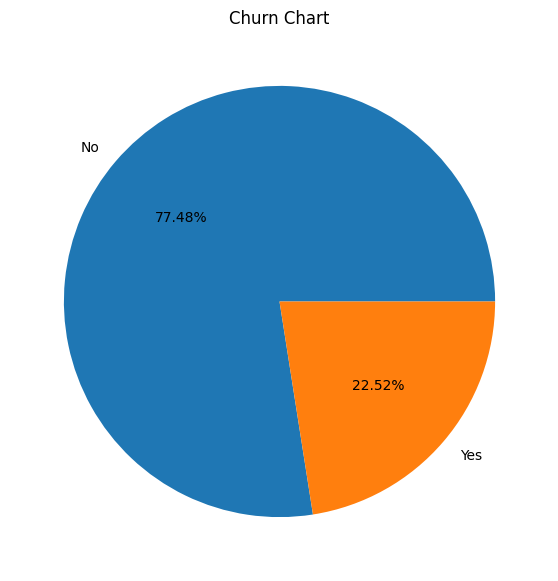

In [13]:
plt.figure(figsize =(6,6))

# value counts for each unique values in Churn
pie_data = churn_data["Churn"].value_counts()

# pie chart
plt.figure(figsize=(7,7))
plt.title("Churn Chart")
plt.pie(pie_data,labels = pie_data.index,autopct = "%1.2f%%")

We can see that there is moderate class imbalance, where No churn is approximately 77.5% and churn is approximately 22.5%. This tells us that from this train set 77.5% Customers are not Churned and other remaining are churned

###  2.2. Numerical Variable

#### 2.2.1 Tenure Vs Churn

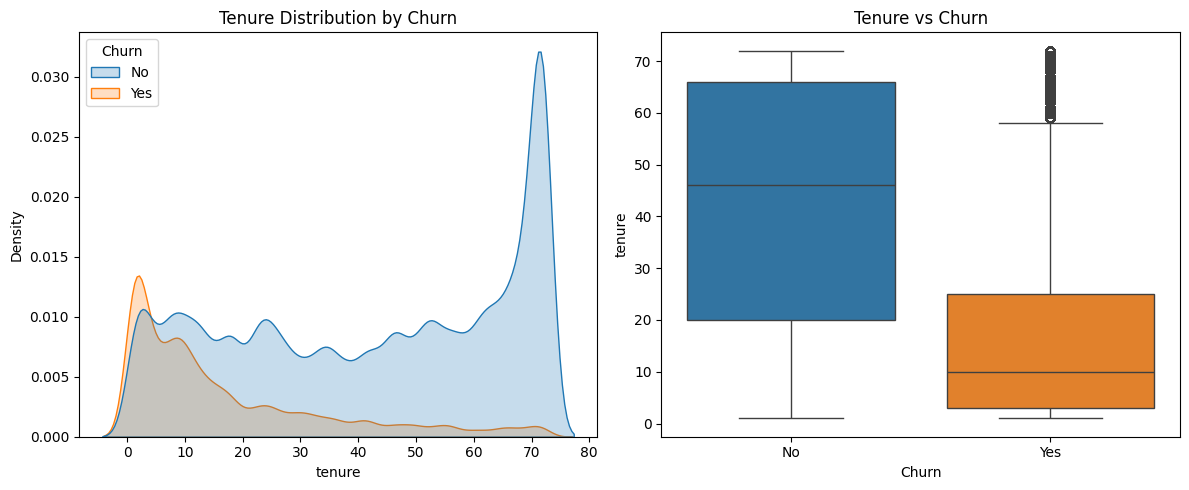

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Tenure Distribution by Churn")
axes[1].set_title("Tenure vs Churn")

# KDE plot
sns.kdeplot(data=churn_data, x="tenure", hue="Churn", fill=True, ax=axes[0])

# Boxplot
sns.boxplot(data=churn_data, x="Churn", y="tenure",hue ="Churn", ax=axes[1])

plt.tight_layout()

From the data, we observe a clear relationship between tenure and churn. Customers with lower tenure are significantly more likely to churn, as churners are heavily concentrated at early tenure periods. In contrast, non-churners tend to have much higher tenure, with a substantially higher median. This suggests that the longer a customer stays, the less likely they are to churn.

#### 2.2.2 Total Charges vs Churn

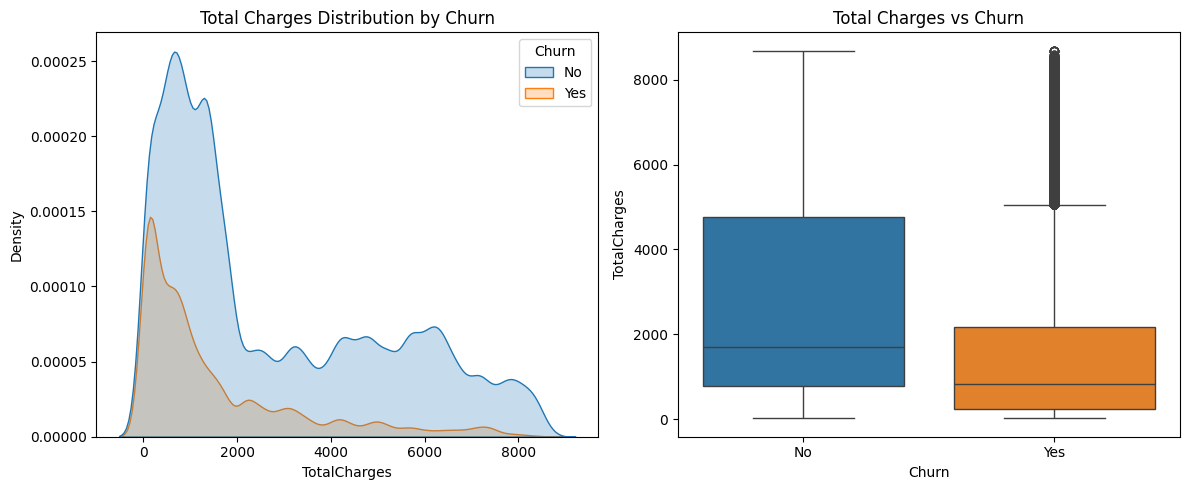

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Total Charges Distribution by Churn")
axes[1].set_title("Total Charges vs Churn")

# KDE plot
sns.kdeplot(data=churn_data, x="TotalCharges", hue="Churn", fill=True, ax=axes[0])

# Boxplot
sns.boxplot(data=churn_data, x="Churn", y="TotalCharges",hue ="Churn", ax=axes[1])

plt.tight_layout()

Both distributions of Total Charges by Churn are right-skewed, indicating that most customers have relatively low total charges. However, churners are much more concentrated at lower values, while non-churners span a wider range and have a higher median. This suggests that customers with lower total charges are more likely to churn. Since Total Charges is closely related to tenure, this pattern likely reflects that newer customers are more prone to churn.

#### 2.2.3 Monthly Charges vs Churn

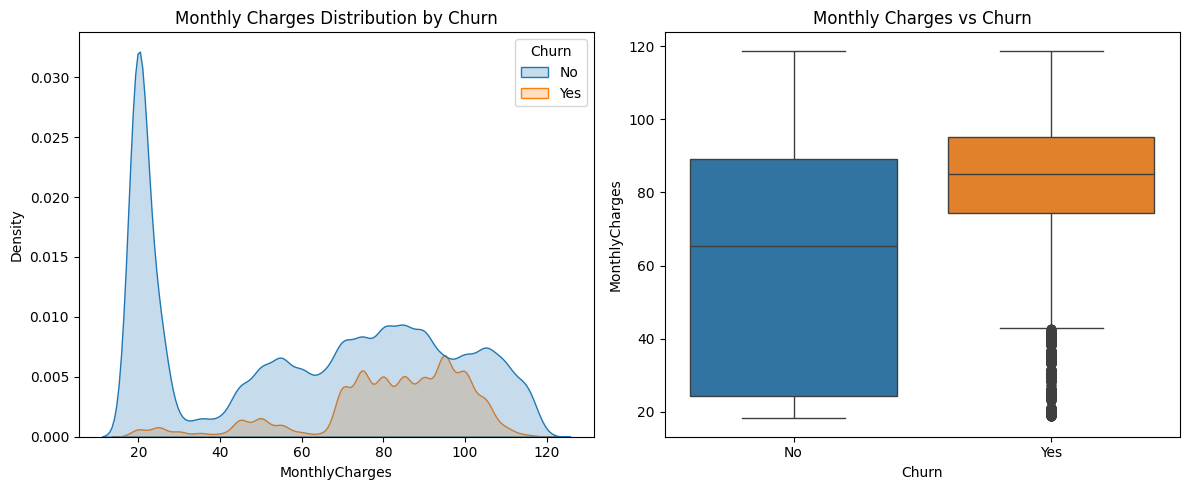

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Monthly Charges Distribution by Churn")
axes[1].set_title("Monthly Charges vs Churn")

# KDE plot
sns.kdeplot(data=churn_data, x="MonthlyCharges", hue="Churn", fill=True, ax=axes[0])

# Boxplot
sns.boxplot(data=churn_data, x="Churn", y="MonthlyCharges",hue ="Churn", ax=axes[1])

plt.tight_layout()

From the data, we observe a clear relationship between Monthly Charges and churn. Customers with higher Monthly Charges are significantly more likely to churn, as churners are heavily concentrated at higher charge levels. In contrast, non-churners tend to have much lower Monthly Charges, with a substantially lower median. This suggests that the higher a customer’s monthly payment, the more likely they are to churn.

#### 2.2.4 Senior Citizen vs Churn

<Axes: title={'center': 'Senior Citizen by Churn'}, xlabel='SeniorCitizen', ylabel='percent'>

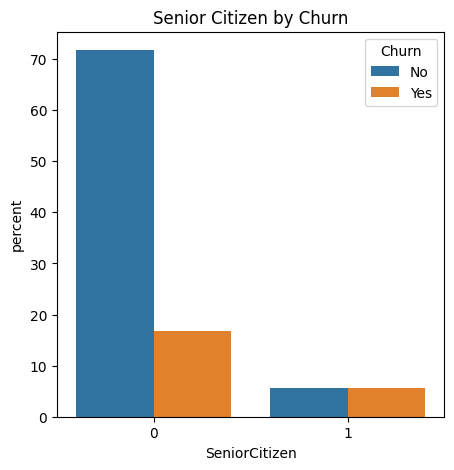

In [17]:
plt.figure(figsize=(5, 5))
plt.title("Senior Citizen by Churn")

# bar chart
sns.countplot(data=churn_data, x="SeniorCitizen", hue="Churn", stat="percent")

While non-senior customers contribute more to total churn due to their larger numbers, senior citizens have a higher churn rate proportionally, making them more likely to churn.

### 2.3 Categorical Variables

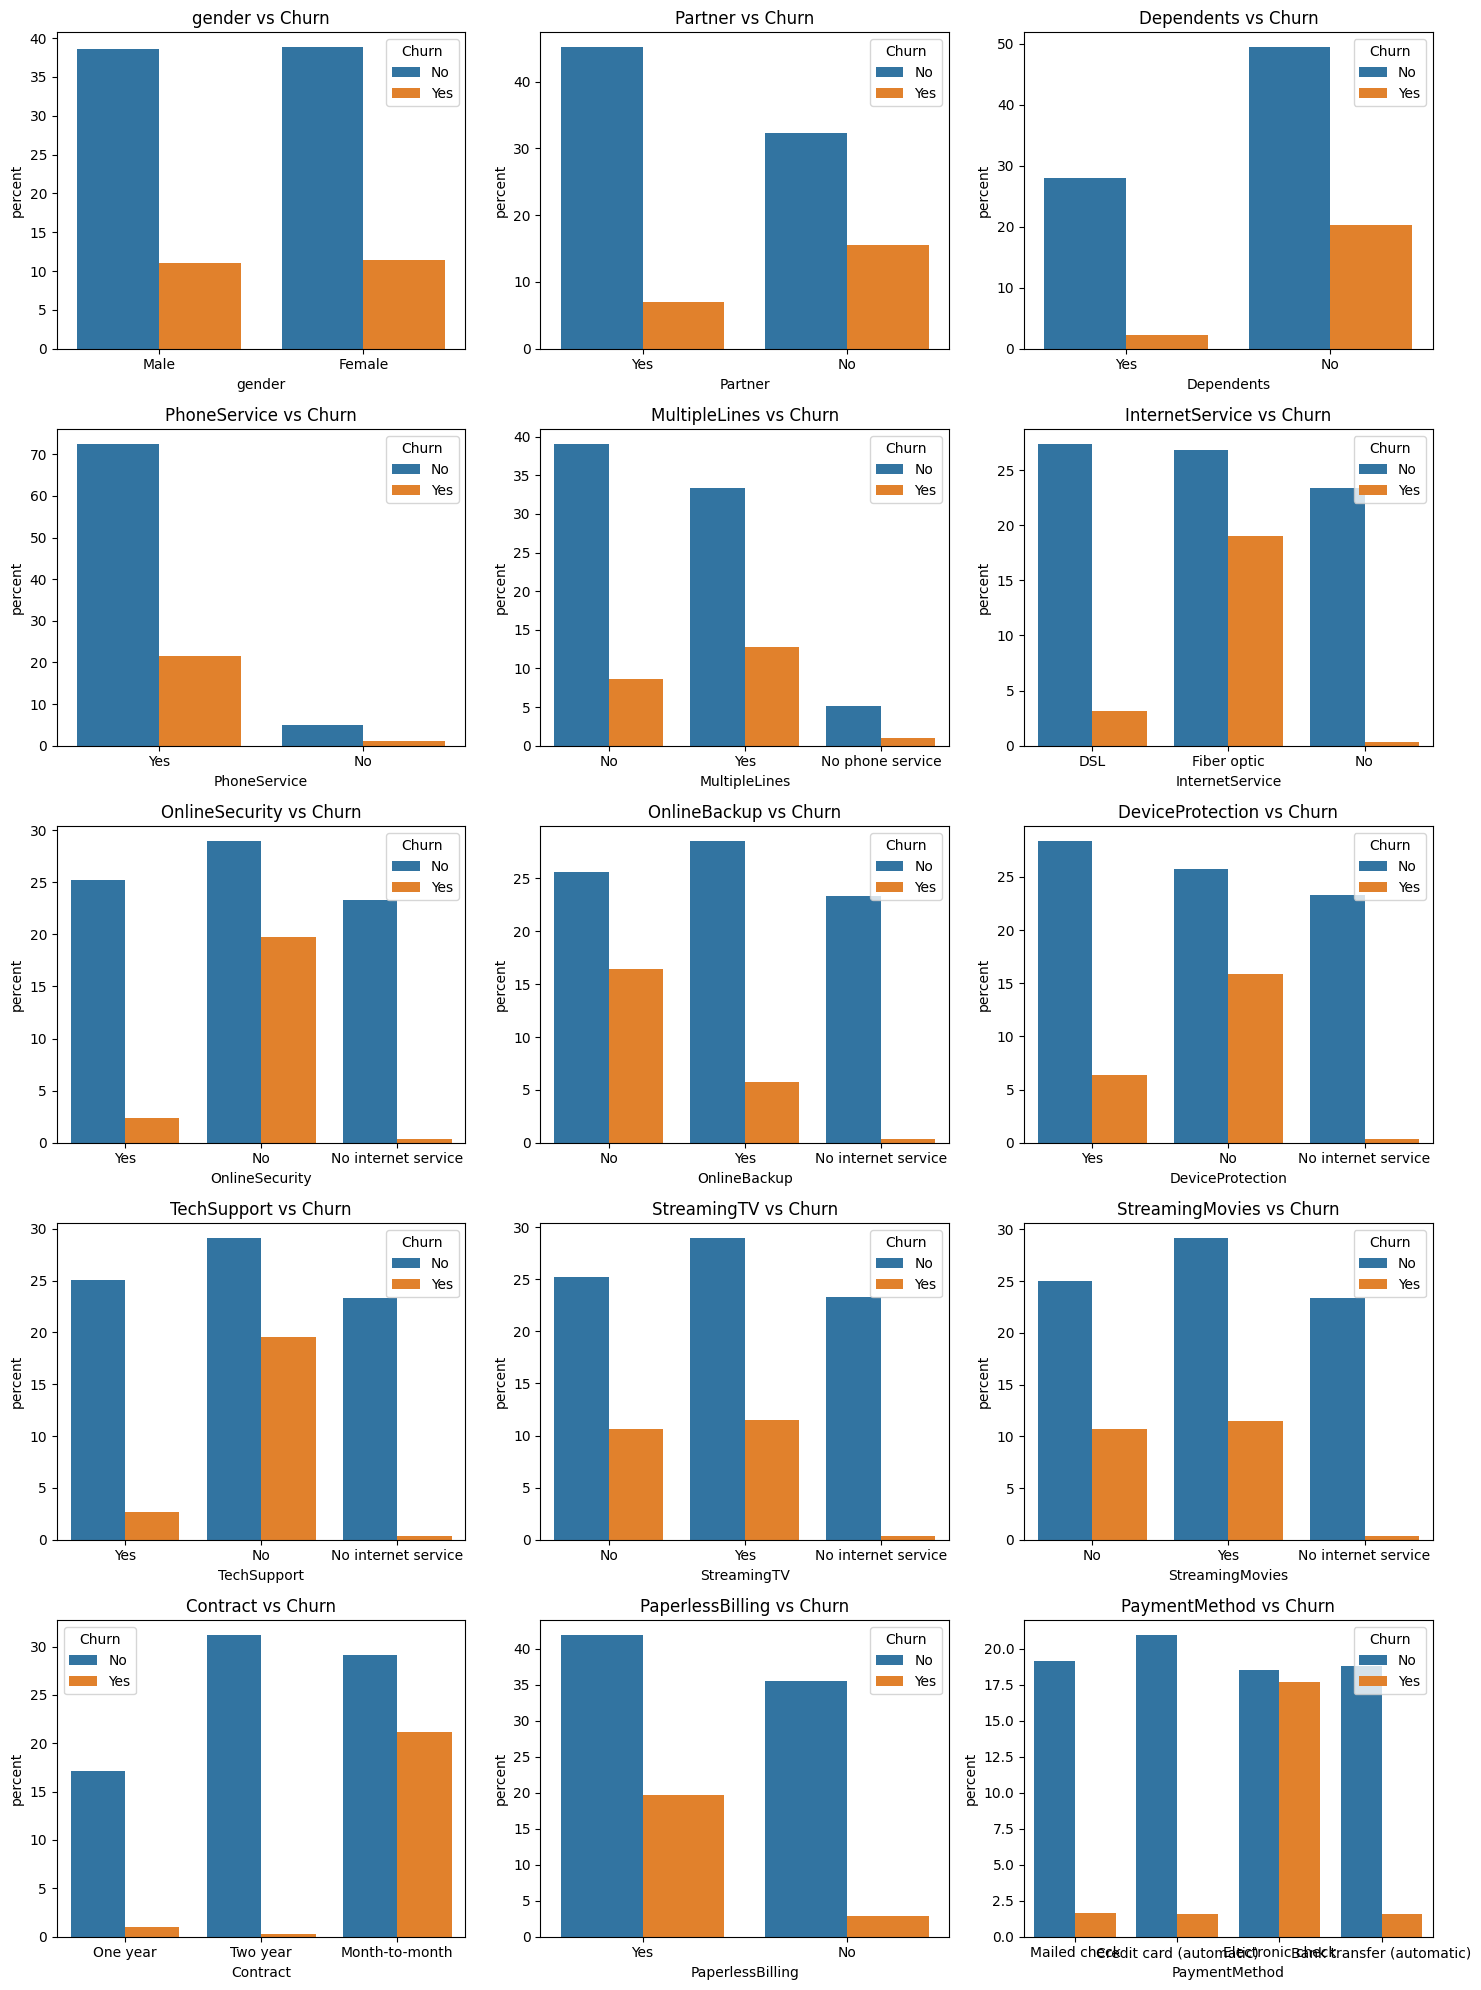

In [18]:
# cat feature
cat_vis = cat_cols[:len(cat_cols)-1]

fig,axes = plt.subplots(5,3, figsize=(15,20))

# plotting all feature in one go
index = 0
for i  in range(5):
    for j in range(3):
        axes[i,j].set_title(f"{cat_vis[index]} vs Churn")
        sns.countplot(data=churn_data, x=cat_vis[index], hue="Churn", ax=axes[i,j], stat="percent")
        index = index+1

plt.tight_layout()

The bar charts illustrate the relationship between various categorical features and customer churn.

We observe that **gender has no significant impact on churn**, as both males and females exhibit similar churn rates.

However, customer relationships play an important role. Customers **without partners or dependents are more likely to churn** compared to those with partners or dependents, suggesting that stronger household ties may increase customer retention.

In terms of services, customers with **phone service and multiple lines show slightly higher churn**, although the difference is not very pronounced.

A more noticeable pattern appears in internet services. Customers using **fiber optic internet have the highest churn rates**, followed by DSL users, while those without internet service churn the least. This suggests that higher-tier or potentially more expensive services may be associated with increased churn.

Security and support-related features show a strong relationship with churn. Customers **without Online Security, Online Backup, Device Protection, and Tech Support are significantly more likely to churn**, indicating that these value-added services may improve customer retention.

For streaming services, customers who stream TV or movies show **only a slight increase in churn**, suggesting that these features have minimal impact on customer decisions.

Contract type has one of the strongest effects: customers on **month-to-month contracts are far more likely to churn**, while those on one-year and especially two-year contracts have much lower churn rates. This highlights the importance of long-term commitments in reducing churn.

Additionally, customers using **paperless billing** tend to churn more than those who do not.

Finally, payment method plays a role, with customers using **electronic checks showing the highest churn rates** compared to other payment methods.


<center>
<dir style="background-color:#ADD8E6;padding:10px;color:black;border-radius:5px">

## **3. PreProcessing and Feature Engineering**

</dir>
</center>

### 3.1 Actual Processing  and Feature Engineering

In [27]:
import sys
sys.path.append("..")

from src.preprocessing import *
from src.utils import *

In [26]:

X = churn_data.copy()
y = X.pop("Churn")

# encoding
y = targetPrepocessing(y)
# new variable
X = newDerivedVariables(X)
# cat processing
X = catPreprocessing(X, cat_vis)
# split
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [28]:
numerical_col = ["MonthlyCharges", "TotalCharges", "tenure"]
scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train[numerical_col])
X_test_scaled = scale.transform(X_test[numerical_col])

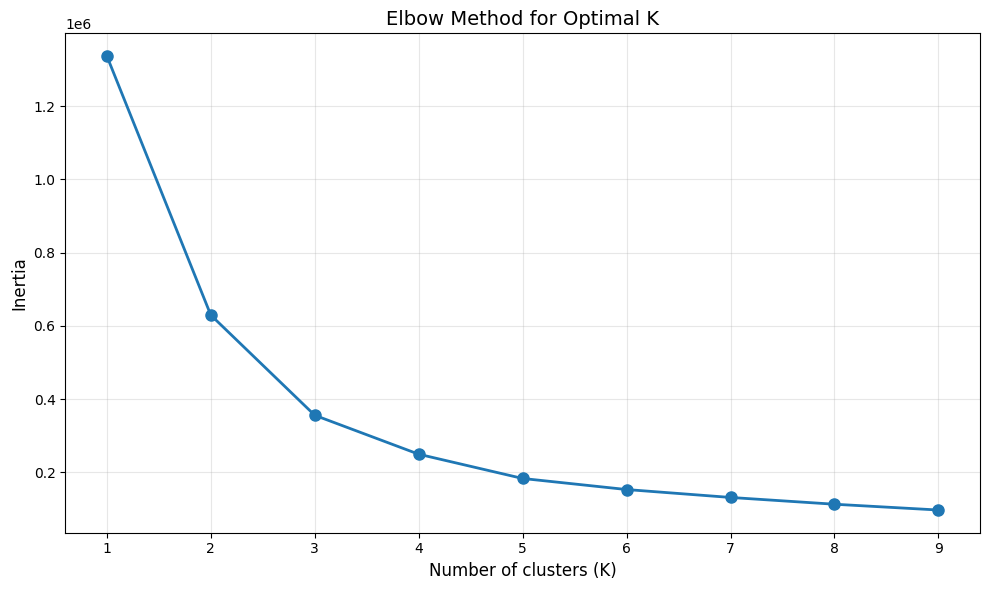

In [29]:
# choosing K in K-means
selectingK(X_train_scaled)

In [22]:
# our k-means
km = KMeans(n_clusters=3, random_state=2026)
X_train["cluster"]=km.fit_predict(X_train_scaled)
X_test["cluster"]=km.predict(X_test_scaled)

In [23]:
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AverageCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,cluster
id,,,,,,,,,,,,,,,,,,,,,
364824,0,35,19.40,741.50,21.185714,1,0,1,0,1,...,1,0,0,1,0,0,1,0,0,2
191807,0,16,100.50,1536.75,96.046875,0,1,0,1,1,...,1,0,0,0,1,0,0,1,0,1
555097,0,66,108.95,7104.20,107.639394,1,0,0,1,0,...,0,0,1,0,1,1,0,0,0,0
181345,0,9,70.80,651.55,72.394444,1,0,1,0,1,...,1,0,0,1,0,0,0,1,0,1
8165,0,70,91.65,6293.75,89.910714,0,1,0,1,1,...,0,0,1,1,0,0,1,0,0,0


<center>
<dir style="background-color:#ADD8E6;padding:10px;color:black;border-radius:5px">

## **4. Model Building**

</dir>
</center>

### Random Forest

In [24]:
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

In [ ]:
rf = RandomForestClassifier(random_state=42,n_jobs=-1,verbose=1)

rf_param ={
    "n_estimators":[100,500,1000],
    "max_depth": [3,5,7,10,None],
    "class_weight":["balanced", None],
    "min_samples_split":[2,5,10,20],
}

In [ ]:
rf_model = RandomizedSearchCV(estimator=rf,param_distributions=rf_param,scoring="roc_auc",n_jobs=5,verbose=1,random_state=42,cv=5,n_iter=20)
rf_model.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\litho\anaconda3\envs\ChurnPrediction\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
11 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "c:\Users\litho\anaconda3\envs\ChurnPrediction\Lib\site-packages\joblib\_utils.py", line 109, in __call__
    return self.func(**kwargs)
           ~~~~~~~~~^^^^^^^^^^
  File "c:\Users\litho\anaconda3\envs\ChurnPrediction\Lib\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
            ~~~~^^^^^^^^^^^^^^^^^
 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","RandomForestC...42, verbose=1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', None], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 500, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [27]:
rf_model.best_score_

np.float64(0.9123631347505364)

In [28]:
preds_rf = rf_model.predict_proba(X_test)
score_rf = roc_auc_score(y_test, preds_rf[:,1])


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.8s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    2.0s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    3.7s
[Parallel(n_jobs=12)]: Done 1000 out of 1000 | elapsed:    4.8s finished


### XGBoost

In [29]:
xgb_ = xgb.XGBClassifier(random_state=42,n_jobs=-1)
# searching for best parameter in XGBoost

xgp_param = {
    "n_estimators":[100,500,1000],
    "max_depth":[3,5,7,10,None],
    "learning_rate":[0.01, 0.05,0.1],
    "reg_alpha":[0.001,0.01,0.1],
    "reg_lambda":[0.001,0.01,0.1],
}


In [30]:

xgb_model = RandomizedSearchCV(estimator = xgb_, n_jobs=-1,cv=5,param_distributions=xgp_param,verbose=1,random_state=42,n_iter=20)
xgb_model.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 500, ...], 'reg_alpha': [0.001, 0.01, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here..

In [31]:
xgb_model.best_score_

np.float64(0.860965566762782)

In [32]:
preds_xgb = xgb_model.predict_proba(X_test)
score_xgb = roc_auc_score(y_test, preds_xgb[:,1])

### CatBoost

In [33]:

cb_estimator =cb.CatBoostClassifier(random_state=42,verbose=False)
# catboost

cat_param ={
    "iterations":[100,500,1000],
    "max_depth":[3,5,7,10,None],
    "learning_rate":[0.01,0.05,0.1],
    "l2_leaf_reg":[0.001,0.01,0.1],
}



In [34]:
cb_model = RandomizedSearchCV(estimator=cb_estimator,cv=5,param_distributions=cat_param,n_jobs=-1,random_state=42,verbose=1,n_iter=20)
cb_model.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostClass...verbose=False)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'iterations': [100, 500, ...], 'l2_leaf_reg': [0.001, 0.01, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versi

In [35]:
cb_model.best_score_

np.float64(0.8609251758686847)

In [36]:
preds_cb = cb_model.predict_proba(X_test)
score_cb = roc_auc_score(y_test, preds_cb[:,1])

In [37]:
score_cb

0.9166805690194169

### LightGBM

In [38]:
lgb_estimator = lgb.LGBMClassifier(random_state=42,verbose=1,n_jobs=-1)

lgb_param = {
    "n_estimators":[100,500,1000],
    "learning_rate":[0.01,0.05,0.1],
    "num_leaves":[i for i in range(1,101)],
    "lambda_l1":[0.01,0.1,0.001],
    "lambda_l2":[0.001,0.01,0.1],
    "max_depth":[3,5,7,10,None],
}



In [39]:
lgb_model = RandomizedSearchCV(estimator=lgb_estimator,cv=5,param_distributions=lgb_param,n_jobs=-1,random_state=42,verbose=1,n_iter=20)
lgb_model.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Warning] lambda_l1 is set=0.01, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.01
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.01, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.01
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Info] Number of positive: 100487, number of negative: 345158
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034312 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 968
[LightGBM] [Info] Number of data points in the train set: 445645, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225487 -> initscore=-1.233974
[LightGBM] [In

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...42, verbose=1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'lambda_l1': [0.01, 0.1, ...], 'lambda_l2': [0.001, 0.01, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

In [40]:
lgb_model.best_score_

np.float64(0.8607366850295639)

In [41]:
preds_lgb = lgb_model.predict_proba(X_test)
score_lgb = roc_auc_score(y_test, preds_lgb[:,1])

c:\Users\litho\anaconda3\envs\ChurnPrediction\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] lambda_l1 is set=0.01, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.01
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1


In [42]:
score_lgb

0.9165426629974985

## Report

In [43]:
train_score = [rf_model.best_score_,xgb_model.best_score_,cb_model.best_score_,lgb_model.best_score_]
scores =[score_rf,score_xgb,score_cb,score_lgb]
models =["Random Forest","XGBoost","CatBoost","LightGBM"]

result =pd.DataFrame({"Training Score":train_score,"Test Score":scores}, index=models)

In [44]:
result.head(5)

,Training Score,Test Score
Random Forest,0.912363,0.912743
XGBoost,0.860966,0.916605
CatBoost,0.860925,0.916681
LightGBM,0.860737,0.916543
